In [1]:
import pandas as pd

#load the dataset using the correct file path to ensure data is loaded properly
#使用正确文件路径加载数据集以确保数据能被正确加载
file_path = r'C:\Users\yuentolong\Dataset .csv'
data = pd.read_csv(file_path,encoding = 'latin-1')
data.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
#Get the data of top 5 cuisines
#得到前五名美食的数据
cuisines_counts = data['Cuisines'].value_counts()
top_five_cuisine = cuisines_counts.head(5)
top_five_cuisine

North Indian             936
North Indian, Chinese    511
Chinese                  354
Fast Food                354
North Indian, Mughlai    334
Name: Cuisines, dtype: int64

In [3]:
#Calculate the percentage of restaurant service each top cuisines
#计算各个提供top美食的餐厅的百分比
total_restaurant = len(data)
percentage_top_five_restaurant = (top_five_cuisine / total_restaurant)*100
percentage_top_five_restaurant

North Indian             9.800021
North Indian, Chinese    5.350225
Chinese                  3.706418
Fast Food                3.706418
North Indian, Mughlai    3.497016
Name: Cuisines, dtype: float64

In [4]:
#Create the dataframe about the top cuisines
#生成Top5菜品的数据框架
results_top5_cuisines = pd.DataFrame({
    'cuisines':top_five_cuisine.index,
    'counts':top_five_cuisine.values,
    'percentage':percentage_top_five_restaurant.values
})

#Check the dataframe 
#检查数据框架
print(results_top5_cuisines) 

#Create the CSV file about the top 5 cuisines
#生成top5菜品的CSV文件
results_top5_cuisines.to_csv('top5_cuisines_results.csv',index = False) #Create the CSV file without saving the index #生成CSV文件，不保存索引


                cuisines  counts  percentage
0           North Indian     936    9.800021
1  North Indian, Chinese     511    5.350225
2                Chinese     354    3.706418
3              Fast Food     354    3.706418
4  North Indian, Mughlai     334    3.497016


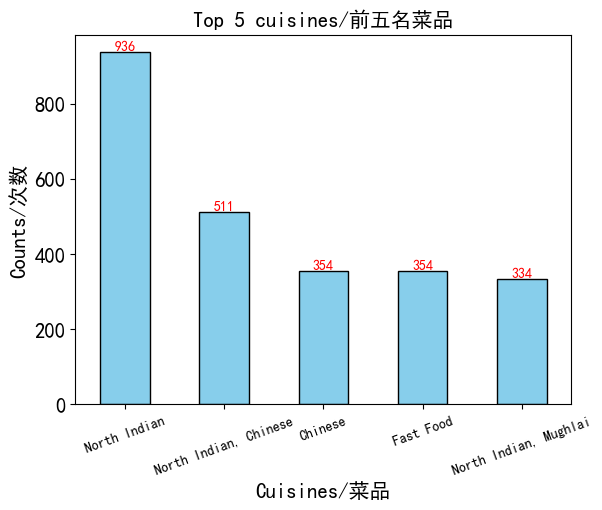

In [5]:
#Generate the visualization of the top 5 cuisines
#生成前五名菜品的可视化数据
import matplotlib.pyplot as plt
#The chart can display Chinese characters
#让图表可显示中文中文字符
plt.rcParams['font.sans-serif'] = 'SimHei'  

#Plotting method one 
#绘图方法一
#Use the enumerate loop and the plot function to plot the data instead of using figure function
#使用plot函数和enumerate循环进行绘图而代替使用figure
top_five_cuisine.plot(kind = 'bar',fontsize = 15,color = 'skyblue',edgecolor = 'black')
for x,y in enumerate(top_five_cuisine): 
    plt.text(x,y,y,ha = 'center',va = 'bottom',color = 'red')
    plt.title('Top 5 cuisines/前五名菜品',fontsize = 15)
    plt.xlabel('Cuisines/菜品',fontsize = 15)
    plt.ylabel('Counts/次数',fontsize = 15)
    plt.xticks(rotation = 20,fontsize = 10)

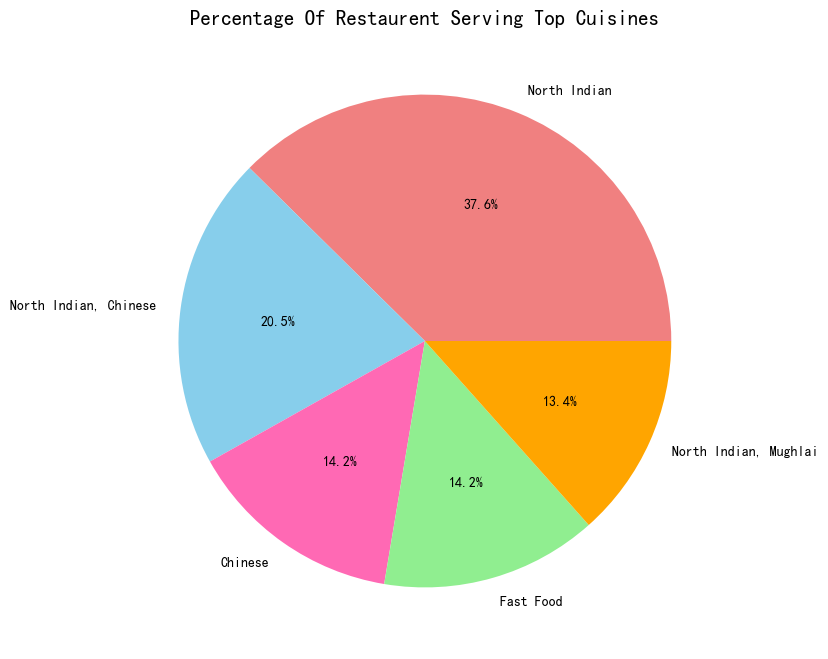

In [6]:
#the percentage of restaurant serving cuisines data for visualization
#提供前五名菜品餐厅数据的可视化
dataframe = pd.read_csv('top5_cuisines_results.csv')

percentage = dataframe['percentage']
cuisines = dataframe['cuisines']

plt.figure(figsize = (8,8))
plt.pie(percentage,labels = cuisines,autopct = '%0.1f%%',startangle = 0,colors = ['lightcoral','skyblue','hotpink','lightgreen','orange'])
plt.title('Percentage Of Restaurent Serving Top Cuisines',fontsize = 15)
plt.show()

In [7]:
#count the city id
#对城市ID进行计数
city_counts = data['City'].value_counts()
city_counts.head(10)

New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: City, dtype: int64

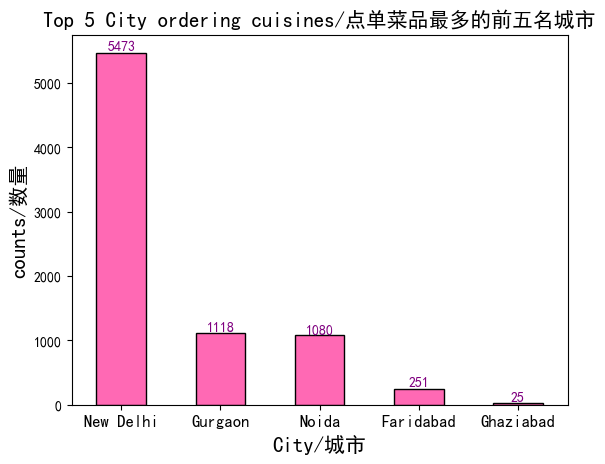

In [8]:
#Top5 city's data for visualization
#城市top5数据可视化
#Generating method one #方法一
city_counts.head(5).plot(kind = 'bar',color = 'hotpink',edgecolor = 'black')
plt.xticks(rotation = 0,fontsize = 12)
for x,y in enumerate(city_counts.head(5)):
    plt.text(x,y,y,ha = 'center',va ='bottom',color = 'purple')
    plt.title('Top 5 City ordering cuisines/点单菜品最多的前五名城市',fontsize = 15)
    plt.xlabel('City/城市',fontsize = 15)
    plt.ylabel('counts/数量',fontsize = 15)

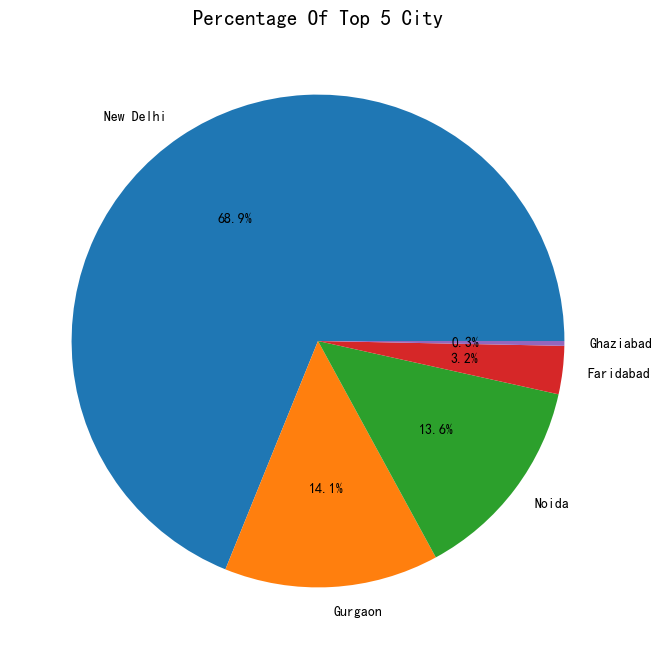

In [9]:
#Plot a pie chart of top 5 city distribution #生成top5城市的分布
#Generating method two #方法二
percentage_city = (city_counts / city_counts.sum()) *100

# percentage_city.head(5)

dataframe1 = pd.DataFrame({
    'city':percentage_city.head(5).index,
    'percentage':percentage_city.head(5).values,
})

percentage1 = dataframe1['percentage']
city1 = dataframe1['city']

plt.figure(figsize = (8,8))
plt.pie(percentage1,labels = city1,autopct = '%0.1f%%',startangle = 0)
plt.title('Percentage Of Top 5 City',fontsize = 15)
plt.show()